**SQL, Python, and Statistics Project**

*Analysis of taxi ride data in Chicago using SQL for data extraction, Python for data exploration and visualization, and statistics for hypothesis testing, evaluating the impact of weather conditions on average trip duration.*




**1. Importing Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

**2. Data Reading**

In [2]:
company = pd.read_csv('/datasets/project_sql_result_01.csv')
neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')
rides = pd.read_csv('/datasets/project_sql_result_07.csv')

**3.Analyzing the Data**

**3.1 Taxi Companies**

In [3]:
company.head()
company.info()
company.describe()
company.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


company_name    0
trips_amount    0
dtype: int64

**3.2 Neighborhoods**

In [4]:
neighborhoods.head()
neighborhoods.info()
neighborhoods.describe()
neighborhoods.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


dropoff_location_name    0
average_trips            0
dtype: int64

**3.3 Races to O'Hare**

In [5]:
rides.head()
rides.info()
rides.describe()
rides.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64

In [6]:
rides['start_ts'] = pd.to_datetime(rides['start_ts'])
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB


The 'start_ts' column was converted from type 'object' to 'datetime', allowing manipulation of dates and times, as well as identifying runs performed on Saturdays to help in statistical analysis.

**4.Data Type Verification**

In [7]:
company.dtypes

company_name    object
trips_amount     int64
dtype: object

In [8]:
neighborhoods.dtypes

dropoff_location_name     object
average_trips            float64
dtype: object

In [9]:
rides.dtypes

start_ts              datetime64[ns]
weather_conditions            object
duration_seconds             float64
dtype: object

**5.Exploratory Data Analysis**

**5.1 Taxi Companies**

In [10]:
company.sort_values(
    by='trips_amount',
    ascending = False
).head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


**5.2 Top 10 Neighborhoods**

In [11]:
top10 = neighborhoods.sort_values(
    by='average_trips',
    ascending = False
).head(10)

print(top10)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


**6.Visualization**

**6.1 Number of Rides per Company**

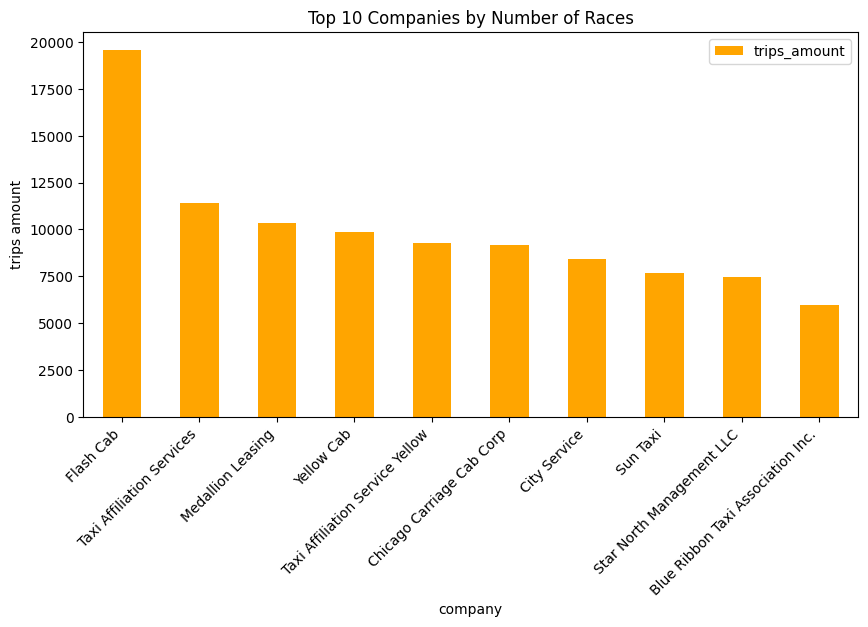

In [12]:
top_companies = company.sort_values(
    by='trips_amount',
    ascending = False
).head(10).set_index('company_name')

top_companies.plot(
    kind = 'bar',
    figsize =(10,5),
    color = 'orange',
    xlabel='company name',
    ylabel='trips amount'
    
)

plt.title('Top 10 Companies by Number of Races')
plt.xlabel('company')
plt.ylabel('trips amount')
plt.xticks(rotation=45, ha='right')
plt.show()


The taxi companies with the highest number of rides are Flash Cab and Taxi Affiliation Services.

**6.2 Top 10 Neighborhoods by Destination**

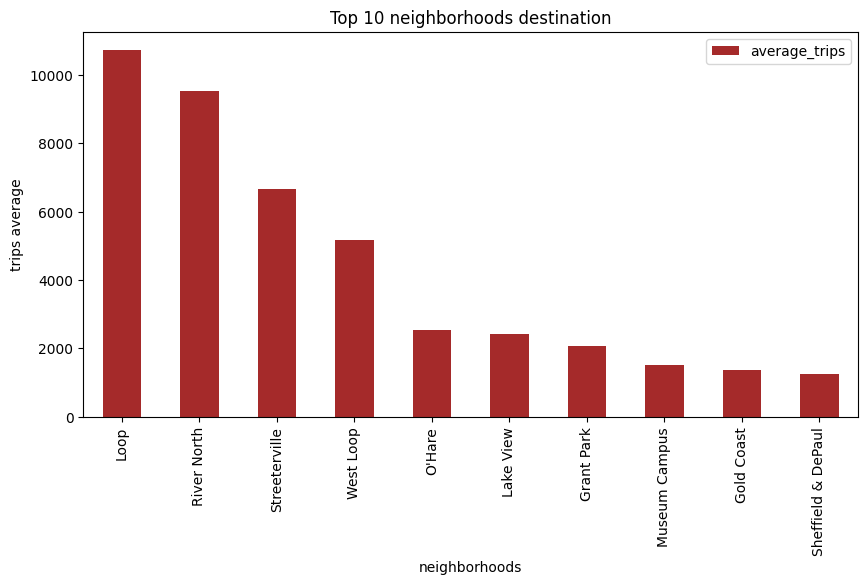

In [13]:
top10 = neighborhoods.sort_values(
    by='average_trips',
    ascending = False
).head(10)

top10.plot(
    kind = 'bar',
    figsize =(10,5),
    color = 'brown',
    x = 'dropoff_location_name',
    y = 'average_trips'
    
)

plt.title('Top 10 neighborhoods destination')
plt.xlabel('neighborhoods')
plt.ylabel('trips average')
plt.show()


As can be seen, the destination cities with the most rides are Loop and River North.

**7. Hypothesis Testing**

**7.1 Formulation of Hypotheses**

*Teste Hipótese Bicaudal*

*Ho - A duração média das corridas é igual em sábados chuvosos e não chuvosos. Nada muda! (Hipótese nula)*

*H1 - A duração média das corridas é diferenfe em sábados chuvosos e não chuvosos. Houve mudança! (Hipótese alternativa)*

*Nível de significância geral: 0,05*



**7.2 Separation of Groups**

In [14]:
rides['weather_conditions'].unique()
#rides['duration_seconds']

array(['Good', 'Bad'], dtype=object)

In [15]:
rides['day_of_week'] = rides['start_ts'].dt.day_name()

In [16]:
Saturday_rides = rides[
    rides['day_of_week'] == 'Saturday'
]

In [17]:
Saturday_rides.head()

,start_ts,weather_conditions,duration_seconds,day_of_week
0,2017-11-25 16:00:00,Good,2410.0,Saturday
1,2017-11-25 14:00:00,Good,1920.0,Saturday
2,2017-11-25 12:00:00,Good,1543.0,Saturday
3,2017-11-04 10:00:00,Good,2512.0,Saturday
4,2017-11-11 07:00:00,Good,1440.0,Saturday


In [18]:
rainy = Saturday_rides[
   Saturday_rides['weather_conditions'] == 'Bad'
]['duration_seconds']


good = Saturday_rides[
   Saturday_rides['weather_conditions'] == 'Good'
]['duration_seconds']

print('Races in Rain:', len(rainy))
print('Races without Rain:', len(good))

Races in Rain: 180
Races without Rain: 888


**7.3 T -Test**

In [19]:
print('averages on rainy days:', rainy.mean())
print('averages on non-rainy days:', good.mean())

averages on rainy days: 2427.2055555555557
averages on non-rainy days: 1999.6756756756756


In [20]:
print(rainy.var())
print(good.var())

520294.086002483
576382.009689509


In [21]:
print(rainy.std())
print(good.std())

721.3141382244514
759.1982677071313


In [22]:
results = stats.ttest_ind(
    rainy,
    good,
    equal_var=False
)
print('valor-p:', results.pvalue)

valor-p: 6.738994326108734e-12


In [23]:
alpha = 0.05

if results.pvalue < alpha:
    print('We reject the null hypothesis.')
else:
    print('We cannot reject the null hypothesis.')

We reject the null hypothesis.


Before conducting the statistical test, the average duration of the runs was calculated for each group analyzed.
As can be observed, the runs performed on rainy days had a different average duration than the runs performed on favorable days. 
This difference motivated the application of the t-test to verify if it is statistically significant.

A t-test for two independent samples was applied to verify if the average duration of rides between the Loop neighborhood and O'Hare International Airport differs between Saturdays on favorable and unfavorable days.
The p-value obtained was 6.738994326108734e-12, a value significantly lower than the adopted significance level 0.05.
Therefore, the null hypothesis was rejected.

**8. Conclusions**

This project used SQL queries, data analysis with Python, and hypothesis testing to identify patterns in taxi rides in the city of Chicago.

Through exploratory analysis, it was possible to identify the companies with the highest number of rides and the neighborhoods that concentrate the main passenger destinations.

In addition, a hypothesis test was performed to verify whether weather conditions influence the duration of rides. The results showed that there is a statistically significant difference between rides carried out in favorable and unfavorable weather conditions, indicating that the weather can directly impact travel time.

Therefore, it is concluded that external factors, such as weather conditions, influence the transportation service, highlighting the importance of data analysis to understand ride behavior and assist in decision-making.